In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import mne

In [2]:
base_path = "/Users/omsrivastava/Documents/healthcare_project/psg-ipa-a-polysomnographic-inter-scorer-performance-assessment-database-1.0.0"

data_path = os.path.join(
    base_path,
    "EEG_arousals"
)

psg_path = os.path.join(
    data_path,
    "PSG"
)

annotation_path = os.path.join(
    data_path,
    "Annotations",
    "auto"
)

subjects = ["SN1", "SN2", "SN3", "SN4", "SN5"]

In [4]:
raw_data = {}

for subject in subjects:

    file = os.path.join(
        psg_path,
        subject + "_EEGarousals.edf"
    )

    raw_data[subject] = mne.io.read_raw_edf(
        file,
        preload=True,
        verbose=False
    )

    print(subject, "loaded")

/var/folders/24/4y355sp57bx4wz5p13yfzhk80000gn/T/ipykernel_14180/2017226610.py:10: RuntimeWarning: Channels contain different highpass filters. Highest filter setting will be stored.
  raw_data[subject] = mne.io.read_raw_edf(
/var/folders/24/4y355sp57bx4wz5p13yfzhk80000gn/T/ipykernel_14180/2017226610.py:10: RuntimeWarning: Channels contain different lowpass filters. Lowest filter setting will be stored.
  raw_data[subject] = mne.io.read_raw_edf(


SN1 loaded


/var/folders/24/4y355sp57bx4wz5p13yfzhk80000gn/T/ipykernel_14180/2017226610.py:10: RuntimeWarning: Channels contain different highpass filters. Highest filter setting will be stored.
  raw_data[subject] = mne.io.read_raw_edf(
/var/folders/24/4y355sp57bx4wz5p13yfzhk80000gn/T/ipykernel_14180/2017226610.py:10: RuntimeWarning: Channels contain different lowpass filters. Lowest filter setting will be stored.
  raw_data[subject] = mne.io.read_raw_edf(


SN2 loaded


/var/folders/24/4y355sp57bx4wz5p13yfzhk80000gn/T/ipykernel_14180/2017226610.py:10: RuntimeWarning: Channels contain different highpass filters. Highest filter setting will be stored.
  raw_data[subject] = mne.io.read_raw_edf(
/var/folders/24/4y355sp57bx4wz5p13yfzhk80000gn/T/ipykernel_14180/2017226610.py:10: RuntimeWarning: Channels contain different lowpass filters. Lowest filter setting will be stored.
  raw_data[subject] = mne.io.read_raw_edf(


SN3 loaded


/var/folders/24/4y355sp57bx4wz5p13yfzhk80000gn/T/ipykernel_14180/2017226610.py:10: RuntimeWarning: Channels contain different highpass filters. Highest filter setting will be stored.
  raw_data[subject] = mne.io.read_raw_edf(
/var/folders/24/4y355sp57bx4wz5p13yfzhk80000gn/T/ipykernel_14180/2017226610.py:10: RuntimeWarning: Channels contain different lowpass filters. Lowest filter setting will be stored.
  raw_data[subject] = mne.io.read_raw_edf(


SN4 loaded


/var/folders/24/4y355sp57bx4wz5p13yfzhk80000gn/T/ipykernel_14180/2017226610.py:10: RuntimeWarning: Channels contain different highpass filters. Highest filter setting will be stored.
  raw_data[subject] = mne.io.read_raw_edf(
/var/folders/24/4y355sp57bx4wz5p13yfzhk80000gn/T/ipykernel_14180/2017226610.py:10: RuntimeWarning: Channels contain different lowpass filters. Lowest filter setting will be stored.
  raw_data[subject] = mne.io.read_raw_edf(


SN5 loaded


In [6]:
sfreq = 256
epoch_time = 30

epoch_samples = sfreq * epoch_time

print(epoch_samples)

7680


In [10]:
labels = []

for subject in subjects:

    file = os.path.join(
        annotation_path,
        subject + "_EEGarousals_auto.txt"
    )

    df = pd.read_csv(file)

    df.columns = df.columns.str.strip()

    df["Annotation"] = df["Annotation"].str.strip()

    df = df[
        df["Annotation"].str.startswith("Sleep stage")
    ]

    for i in range(len(df)):

        annotation = df.iloc[i]["Annotation"]

        if annotation == "Sleep stage W":
            label = 0
            stage = "W"

        elif annotation == "Sleep stage N1":
            label = 1
            stage = "N1"

        elif annotation == "Sleep stage N2":
            label = 2
            stage = "N2"

        elif annotation == "Sleep stage N3":
            label = 3
            stage = "N3"

        elif annotation == "Sleep stage R":
            label = 4
            stage = "R"

        else:
            continue

        epoch = round(
            df.iloc[i]["Recording onset"] / 30
        )

        labels.append([
            subject,
            int(epoch),
            stage,
            label
        ])

In [11]:
labels_df = pd.DataFrame(
    labels,
    columns=[
        "subject",
        "epoch",
        "stage",
        "label"
    ]
)

print(labels_df.shape)
print(labels_df.head())

(4745, 4)
  subject  epoch stage  label
0     SN1      0     W      0
1     SN1      1     W      0
2     SN1      2     W      0
3     SN1      3     W      0
4     SN1      4     W      0


In [47]:
import numpy as np
from scipy.signal import welch

sfreq = 256
epoch_samples = 30 * sfreq

eog = raw_data["SN1"].get_data(
    picks=["EOG E1-M2", "EOG E2-M2"]
)

epoch = eog[:, :epoch_samples]

print(epoch.shape)

(2, 7680)


In [54]:
eog_features = []

for subject in subjects:

    raw = raw_data[subject]

    eog = raw.get_data(
        picks=["EOG E1-M2", "EOG E2-M2"]
    )

    n_epochs = eog.shape[1] // epoch_samples

    for epoch_no in range(n_epochs):

        start = epoch_no * epoch_samples
        end = start + epoch_samples

        eog1 = eog[0, start:end]
        eog2 = eog[1, start:end]

        # EOG1 time features
        eog1_mean = np.mean(eog1)
        eog1_std = np.std(eog1)
        eog1_min = np.min(eog1)
        eog1_max = np.max(eog1)
        eog1_rms = np.sqrt(np.mean(eog1 ** 2))

        # EOG1 frequency
        freq, power = welch(
            eog1,
            fs=sfreq,
            nperseg=1024
        )

        delta = np.trapz(
            power[(freq >= 0.5) & (freq < 2)],
            freq[(freq >= 0.5) & (freq < 2)]
        )

        theta = np.trapz(
            power[(freq >= 2) & (freq < 4)],
            freq[(freq >= 2) & (freq < 4)]
        )

        alpha = np.trapz(
            power[(freq >= 4) & (freq < 8)],
            freq[(freq >= 4) & (freq < 8)]
        )

        beta = np.trapz(
            power[(freq >= 8) & (freq < 15)],
            freq[(freq >= 8) & (freq < 15)]
        )

        total = delta + theta + alpha + beta

        delta_rel = delta / total
        theta_rel = theta / total
        alpha_rel = alpha / total
        beta_rel = beta / total

        # EOG2 time features
        eog2_mean = np.mean(eog2)
        eog2_std = np.std(eog2)
        eog2_min = np.min(eog2)
        eog2_max = np.max(eog2)
        eog2_rms = np.sqrt(np.mean(eog2 ** 2))

        # EOG2 frequency
        freq, power = welch(
            eog2,
            fs=sfreq,
            nperseg=1024
        )

        delta2 = np.trapz(
            power[(freq >= 0.5) & (freq < 2)],
            freq[(freq >= 0.5) & (freq < 2)]
        )

        theta2 = np.trapz(
            power[(freq >= 2) & (freq < 4)],
            freq[(freq >= 2) & (freq < 4)]
        )

        alpha2 = np.trapz(
            power[(freq >= 4) & (freq < 8)],
            freq[(freq >= 4) & (freq < 8)]
        )

        beta2 = np.trapz(
            power[(freq >= 8) & (freq < 15)],
            freq[(freq >= 8) & (freq < 15)]
        )

        total2 = delta2 + theta2 + alpha2 + beta2

        delta2_rel = delta2 / total2
        theta2_rel = theta2 / total2
        alpha2_rel = alpha2 / total2
        beta2_rel = beta2 / total2

        eog_features.append([
            subject,
            epoch_no,

            eog1_mean,
            eog1_std,
            eog1_min,
            eog1_max,
            eog1_rms,

            delta,
            theta,
            alpha,
            beta,

            delta_rel,
            theta_rel,
            alpha_rel,
            beta_rel,

            eog2_mean,
            eog2_std,
            eog2_min,
            eog2_max,
            eog2_rms,

            delta2,
            theta2,
            alpha2,
            beta2,

            delta2_rel,
            theta2_rel,
            alpha2_rel,
            beta2_rel
        ])

print("Feature extraction completed")

Feature extraction completed


In [55]:
columns = [
    "subject",
    "epoch",

    "eog1_mean",
    "eog1_std",
    "eog1_min",
    "eog1_max",
    "eog1_rms",

    "eog1_delta",
    "eog1_theta",
    "eog1_alpha",
    "eog1_beta",

    "eog1_delta_rel",
    "eog1_theta_rel",
    "eog1_alpha_rel",
    "eog1_beta_rel",

    "eog2_mean",
    "eog2_std",
    "eog2_min",
    "eog2_max",
    "eog2_rms",

    "eog2_delta",
    "eog2_theta",
    "eog2_alpha",
    "eog2_beta",

    "eog2_delta_rel",
    "eog2_theta_rel",
    "eog2_alpha_rel",
    "eog2_beta_rel"
]

eog_feature_df = pd.DataFrame(
    eog_features,
    columns=columns
)

print(eog_feature_df.shape)
print(eog_feature_df.head())

(4746, 28)
  subject  epoch  eog1_mean  eog1_std  eog1_min  eog1_max  eog1_rms  \
0     SN1      0   0.000001  0.000046 -0.000283  0.000229  0.000046   
1     SN1      1   0.000002  0.000061 -0.000242  0.000283  0.000061   
2     SN1      2   0.000002  0.000036 -0.000138  0.000152  0.000036   
3     SN1      3   0.000002  0.000046 -0.000170  0.000213  0.000046   
4     SN1      4   0.000002  0.000044 -0.000204  0.000144  0.000044   

     eog1_delta    eog1_theta    eog1_alpha  ...  eog2_max  eog2_rms  \
0  1.054515e-09  1.896475e-10  6.219311e-11  ...  0.000238  0.000048   
1  1.234052e-09  1.067749e-10  2.083672e-11  ...  0.000212  0.000044   
2  4.534020e-10  5.124008e-11  2.152292e-11  ...  0.000184  0.000030   
3  5.419040e-10  3.217029e-11  1.053209e-11  ...  0.000216  0.000047   
4  9.145834e-10  1.184966e-10  4.040591e-11  ...  0.000115  0.000029   

     eog2_delta    eog2_theta    eog2_alpha     eog2_beta  eog2_delta_rel  \
0  1.052065e-09  1.784235e-10  5.945484e-11  1.97053

In [56]:
print(eog_feature_df.shape)
print(eog_feature_df["subject"].value_counts())

(4746, 28)
subject
SN5    1056
SN4     982
SN3     975
SN2     867
SN1     866
Name: count, dtype: int64


In [58]:
eog_ml_df = eog_feature_df.merge(
    labels_df[["subject", "epoch", "stage", "label"]],
    on=["subject", "epoch"],
    how="inner"
)

In [59]:
print(eog_ml_df.shape)
print(eog_ml_df.head())

(4745, 30)
  subject  epoch  eog1_mean  eog1_std  eog1_min  eog1_max  eog1_rms  \
0     SN1      0   0.000001  0.000046 -0.000283  0.000229  0.000046   
1     SN1      1   0.000002  0.000061 -0.000242  0.000283  0.000061   
2     SN1      2   0.000002  0.000036 -0.000138  0.000152  0.000036   
3     SN1      3   0.000002  0.000046 -0.000170  0.000213  0.000046   
4     SN1      4   0.000002  0.000044 -0.000204  0.000144  0.000044   

     eog1_delta    eog1_theta    eog1_alpha  ...    eog2_delta    eog2_theta  \
0  1.054515e-09  1.896475e-10  6.219311e-11  ...  1.052065e-09  1.784235e-10   
1  1.234052e-09  1.067749e-10  2.083672e-11  ...  6.551369e-10  6.442189e-11   
2  4.534020e-10  5.124008e-11  2.152292e-11  ...  3.650315e-10  3.932102e-11   
3  5.419040e-10  3.217029e-11  1.053209e-11  ...  4.348817e-10  2.149817e-11   
4  9.145834e-10  1.184966e-10  4.040591e-11  ...  3.596518e-10  4.933823e-11   

     eog2_alpha     eog2_beta  eog2_delta_rel  eog2_theta_rel  eog2_alpha_rel  \


In [60]:
print(eog_ml_df["stage"].value_counts())

stage
N2    1905
N3     934
W      796
R      752
N1     358
Name: count, dtype: int64


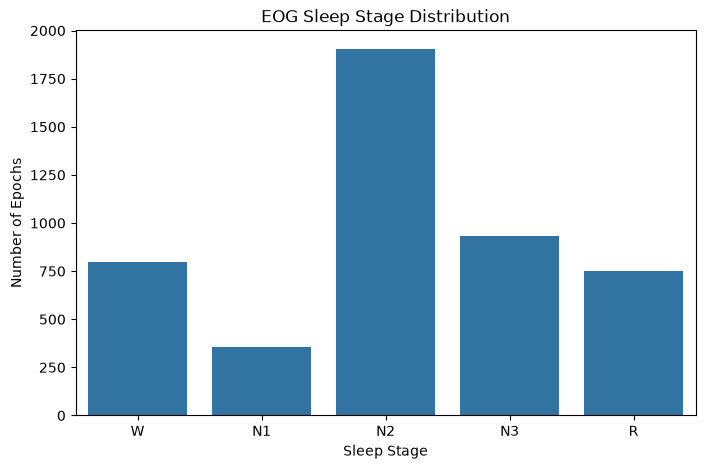

In [64]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=eog_ml_df,
    x="stage"
)

plt.title("EOG Sleep Stage Distribution")
plt.xlabel("Sleep Stage")
plt.ylabel("Number of Epochs")

plt.show()

In [67]:
features_all = [
    "eog1_mean",
    "eog1_std",
    "eog1_min",
    "eog1_max",
    "eog1_rms",
    "eog1_delta",
    "eog1_theta",
    "eog1_alpha",
    "eog1_beta",
    "eog1_delta_rel",
    "eog1_theta_rel",
    "eog1_alpha_rel",
    "eog1_beta_rel",

    "eog2_mean",
    "eog2_std",
    "eog2_min",
    "eog2_max",
    "eog2_rms",
    "eog2_delta",
    "eog2_theta",
    "eog2_alpha",
    "eog2_beta",
    "eog2_delta_rel",
    "eog2_theta_rel",
    "eog2_alpha_rel",
    "eog2_beta_rel"
]

print("Number of features:", len(features_all))

Number of features: 26


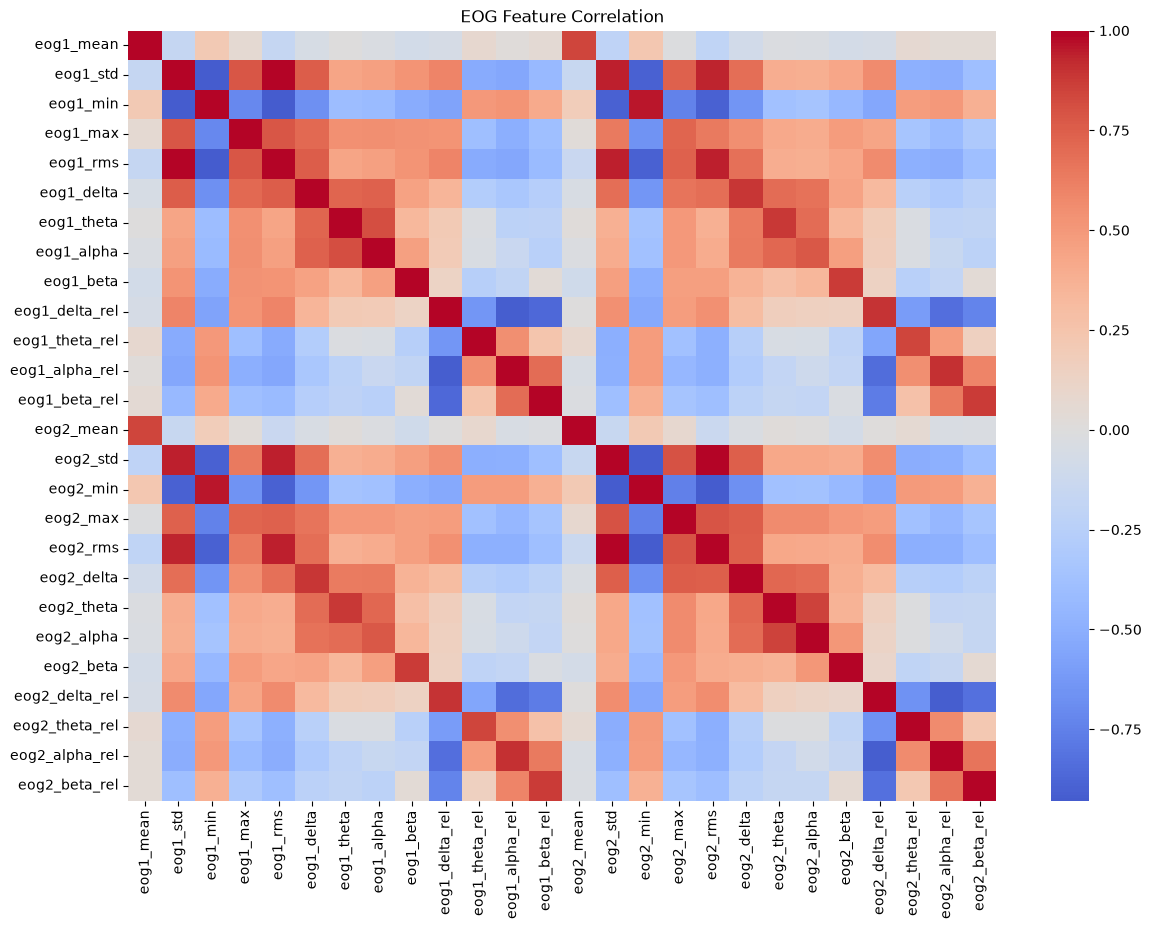

In [70]:
import matplotlib.pyplot as plt
import seaborn as sns

corr = eog_ml_df[features_all].corr()

plt.figure(figsize=(14, 10))

sns.heatmap(
    corr,
    annot=False,
    cmap="coolwarm",
    center=0
)

plt.title("EOG Feature Correlation")
plt.show()

In [71]:
corr_pairs = corr.abs().unstack()

corr_pairs = corr_pairs[
    (corr_pairs < 1.0) &
    (corr_pairs > 0.90)
]

print(corr_pairs.sort_values(ascending=False).head(30))

eog1_std        eog1_rms          0.999723
eog1_rms        eog1_std          0.999723
eog2_rms        eog2_std          0.999509
eog2_std        eog2_rms          0.999509
eog1_min        eog2_min          0.959959
eog2_min        eog1_min          0.959959
eog1_rms        eog2_std          0.940571
eog2_std        eog1_rms          0.940571
eog2_rms        eog1_rms          0.940246
eog1_rms        eog2_rms          0.940246
eog2_std        eog1_std          0.940164
eog1_std        eog2_std          0.940164
                eog2_rms          0.939268
eog2_rms        eog1_std          0.939268
eog2_min        eog2_std          0.928725
eog2_std        eog2_min          0.928725
eog1_std        eog1_min          0.927578
eog1_min        eog1_std          0.927578
eog1_rms        eog1_min          0.927175
eog1_min        eog1_rms          0.927175
eog2_min        eog2_rms          0.926779
eog2_rms        eog2_min          0.926779
eog2_delta_rel  eog2_alpha_rel    0.919938
eog2_alpha_

In [72]:
features_rf = [
    "eog1_mean",
    "eog1_std",
    "eog1_min",
    "eog1_max",

    "eog1_delta",
    "eog1_theta",
    "eog1_alpha",
    "eog1_beta",

    "eog1_delta_rel",
    "eog1_theta_rel",
    "eog1_alpha_rel",
    "eog1_beta_rel",

    "eog2_mean",
    "eog2_std",
    "eog2_min",
    "eog2_max",

    "eog2_delta",
    "eog2_theta",
    "eog2_alpha",
    "eog2_beta",

    "eog2_delta_rel",
    "eog2_theta_rel",
    "eog2_alpha_rel",
    "eog2_beta_rel"
]

print("Features:", len(features_rf))

Features: 24


In [73]:
from sklearn.ensemble import RandomForestClassifier
import pandas as pd

X = eog_ml_df[features_rf]
y = eog_ml_df["label"]

model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight="balanced",
    n_jobs=-1
)

model.fit(X, y)

importance = pd.DataFrame({
    "Feature": features_rf,
    "Importance": model.feature_importances_
})

importance = importance.sort_values(
    "Importance",
    ascending=False
)

print(importance)

           Feature  Importance
19       eog2_beta    0.090890
5       eog1_theta    0.081848
17      eog2_theta    0.062510
7        eog1_beta    0.060560
3         eog1_max    0.056885
11   eog1_beta_rel    0.046230
9   eog1_theta_rel    0.043539
6       eog1_alpha    0.042007
23   eog2_beta_rel    0.041253
21  eog2_theta_rel    0.041096
15        eog2_max    0.039395
2         eog1_min    0.038393
18      eog2_alpha    0.038071
1         eog1_std    0.037735
10  eog1_alpha_rel    0.034623
4       eog1_delta    0.031349
16      eog2_delta    0.029880
13        eog2_std    0.029556
14        eog2_min    0.027736
22  eog2_alpha_rel    0.027328
8   eog1_delta_rel    0.026348
20  eog2_delta_rel    0.026183
12       eog2_mean    0.023721
0        eog1_mean    0.022866


In [74]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report

train_df = eog_ml_df[
    eog_ml_df["subject"] != "SN5"
]

test_df = eog_ml_df[
    eog_ml_df["subject"] == "SN5"
]

X_train = train_df[features_rf]
y_train = train_df["label"]

X_test = test_df[features_rf]
y_test = test_df["label"]

model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight="balanced",
    n_jobs=-1
)

model.fit(X_train, y_train)

ypred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, ypred))

print(
    "Macro F1:",
    f1_score(
        y_test,
        ypred,
        average="macro"
    )
)

print(
    classification_report(
        y_test,
        ypred,
        target_names=["Wake", "N1", "N2", "N3", "REM"]
    )
)

Accuracy: 0.7253787878787878
Macro F1: 0.645387338443793
              precision    recall  f1-score   support

        Wake       0.79      0.81      0.80       183
          N1       0.30      0.37      0.33        68
          N2       0.84      0.78      0.81       492
          N3       0.91      0.60      0.72       208
         REM       0.44      0.80      0.57       105

    accuracy                           0.73      1056
   macro avg       0.66      0.67      0.65      1056
weighted avg       0.77      0.73      0.74      1056



In [78]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score
import pandas as pd

features_all = [
    "eog1_mean",
    "eog1_std",
    "eog1_min",
    "eog1_max",
    "eog1_rms",
    "eog1_delta",
    "eog1_theta",
    "eog1_alpha",
    "eog1_beta",
    "eog1_delta_rel",
    "eog1_theta_rel",
    "eog1_alpha_rel",
    "eog1_beta_rel",
    "eog2_mean",
    "eog2_std",
    "eog2_min",
    "eog2_max",
    "eog2_rms",
    "eog2_delta",
    "eog2_theta",
    "eog2_alpha",
    "eog2_beta",
    "eog2_delta_rel",
    "eog2_theta_rel",
    "eog2_alpha_rel",
    "eog2_beta_rel"
]

subjects = eog_ml_df["subject"].unique()

results = []

for test_subject in subjects:

    train_df = eog_ml_df[
        eog_ml_df["subject"] != test_subject
    ]

    test_df = eog_ml_df[
        eog_ml_df["subject"] == test_subject
    ]

    X_train = train_df[features_all]
    y_train = train_df["label"]

    X_test = test_df[features_all]
    y_test = test_df["label"]

    model = RandomForestClassifier(
        n_estimators=200,
        max_depth=15,
        min_samples_split=5,
        min_samples_leaf=1,
        max_features="log2",
        criterion="gini",
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    )

    model.fit(X_train, y_train)

    ypred = model.predict(X_test)

    accuracy = accuracy_score(y_test, ypred)

    macro_f1 = f1_score(
        y_test,
        ypred,
        average="macro"
    )

    results.append([
        test_subject,
        accuracy,
        macro_f1
    ])

    print(
        test_subject,
        "Accuracy:", round(accuracy, 3),
        "Macro F1:", round(macro_f1, 3)
    )


results_df = pd.DataFrame(
    results,
    columns=[
        "Test Subject",
        "Accuracy",
        "Macro F1"
    ]
)

print("\nResults:")
print(results_df)

print(
    "\nMean Accuracy:",
    results_df["Accuracy"].mean()
)

print(
    "Mean Macro F1:",
    results_df["Macro F1"].mean()
)

SN1 Accuracy: 0.742 Macro F1: 0.655
SN2 Accuracy: 0.603 Macro F1: 0.499
SN3 Accuracy: 0.512 Macro F1: 0.368
SN4 Accuracy: 0.567 Macro F1: 0.465
SN5 Accuracy: 0.707 Macro F1: 0.631

Results:
  Test Subject  Accuracy  Macro F1
0          SN1  0.742197  0.655356
1          SN2  0.603230  0.498613
2          SN3  0.511795  0.367611
3          SN4  0.567210  0.465085
4          SN5  0.707386  0.630814

Mean Accuracy: 0.6263634140591032
Mean Macro F1: 0.5234959090368362


In [83]:
top15_features = [
    "eog2_beta",
    "eog1_theta",
    "eog2_theta",
    "eog1_beta",
    "eog2_alpha",
    "eog1_alpha",
    "eog1_max",
    "eog1_theta_rel",
    "eog2_beta_rel",
    "eog2_theta_rel",
    "eog1_beta_rel",
    "eog1_std",
    "eog2_max",
    "eog1_alpha_rel",
    "eog1_min"
]

print("Number of features:", len(top15_features))

Number of features: 15


In [84]:
X_train = train_df[top15_features]
y_train = train_df["label"]

X_test = test_df[top15_features]
y_test = test_df["label"]

model = RandomForestClassifier(
    n_estimators=200,
    max_depth=15,
    min_samples_split=5,
    min_samples_leaf=1,
    max_features="log2",
    criterion="gini",
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

model.fit(X_train, y_train)

ypred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, ypred))

print(
    "Macro F1:",
    f1_score(
        y_test,
        ypred,
        average="macro"
    )
)

Accuracy: 0.7026515151515151
Macro F1: 0.6297779201352695


In [93]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score
import pandas as pd

results = []

for leaf in [1, 2, 3, 5, 10]:

    for criterion in ["gini", "entropy"]:

        model = RandomForestClassifier(
            n_estimators=200,
            max_depth=20,
            min_samples_split=5,
            min_samples_leaf=leaf,
            max_features="log2",
            criterion=criterion,
            class_weight=None,
            random_state=42,
            n_jobs=-1
        )

        model.fit(
            train_df[features_all],
            train_df["label"]
        )

        ypred = model.predict(
            test_df[features_all]
        )

        accuracy = accuracy_score(
            test_df["label"],
            ypred
        )

        macro_f1 = f1_score(
            test_df["label"],
            ypred,
            average="macro"
        )

        results.append([
            leaf,
            criterion,
            accuracy,
            macro_f1
        ])

        print(
            "Leaf:", leaf,
            "Criterion:", criterion,
            "Accuracy:", round(accuracy, 4),
            "Macro F1:", round(macro_f1, 4)
        )


results_df = pd.DataFrame(
    results,
    columns=[
        "Min Samples Leaf",
        "Criterion",
        "Accuracy",
        "Macro F1"
    ]
)

results_df = results_df.sort_values(
    "Macro F1",
    ascending=False
)

print("\nResults:")
print(results_df) 


Leaf: 1 Criterion: gini Accuracy: 0.7377 Macro F1: 0.6684
Leaf: 1 Criterion: entropy Accuracy: 0.7509 Macro F1: 0.6816
Leaf: 2 Criterion: gini Accuracy: 0.7273 Macro F1: 0.6531
Leaf: 2 Criterion: entropy Accuracy: 0.7434 Macro F1: 0.6649
Leaf: 3 Criterion: gini Accuracy: 0.733 Macro F1: 0.6567
Leaf: 3 Criterion: entropy Accuracy: 0.7396 Macro F1: 0.6643
Leaf: 5 Criterion: gini Accuracy: 0.7443 Macro F1: 0.6738
Leaf: 5 Criterion: entropy Accuracy: 0.7405 Macro F1: 0.6638
Leaf: 10 Criterion: gini Accuracy: 0.7273 Macro F1: 0.6447
Leaf: 10 Criterion: entropy Accuracy: 0.7453 Macro F1: 0.6704

Results:
   Min Samples Leaf Criterion  Accuracy  Macro F1
1                 1   entropy  0.750947  0.681617
6                 5      gini  0.744318  0.673820
9                10   entropy  0.745265  0.670435
0                 1      gini  0.737689  0.668378
3                 2   entropy  0.743371  0.664884
5                 3   entropy  0.739583  0.664342
7                 5   entropy  0.740530  0.6

In [95]:
model = RandomForestClassifier(
    n_estimators=200,
    max_depth=20,
    min_samples_split=5,
    min_samples_leaf=1,
    max_features="log2",
    criterion="entropy",
    class_weight=None,
    random_state=42,
    n_jobs=-1
)

model.fit(
    train_df[features_all],
    train_df["label"]
)

ypred = model.predict(
    test_df[features_all]
)

print("Accuracy:", accuracy_score(
    test_df["label"],
    ypred
))

print("Macro F1:", f1_score(
    test_df["label"],
    ypred,
    average="macro"
))

print("\nClassification Report:")

print(classification_report(
    test_df["label"],
    ypred,
    target_names=["Wake", "N1", "N2", "N3", "REM"]
))

Accuracy: 0.7509469696969697
Macro F1: 0.6816171695897769

Classification Report:
              precision    recall  f1-score   support

        Wake       0.80      0.84      0.82       183
          N1       0.39      0.40      0.39        68
          N2       0.84      0.78      0.81       492
          N3       0.90      0.68      0.77       208
         REM       0.48      0.84      0.61       105

    accuracy                           0.75      1056
   macro avg       0.68      0.71      0.68      1056
weighted avg       0.78      0.75      0.76      1056



[[154   4  12   2  11]
 [ 21  27  14   0   6]
 [ 12  32 383  11  54]
 [  3   0  39 141  25]
 [  2   6   7   2  88]]


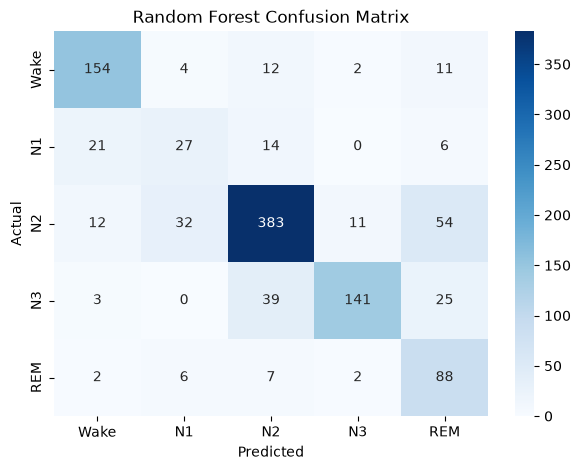

In [96]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(
    test_df["label"],
    ypred
)

print(cm)

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Wake", "N1", "N2", "N3", "REM"],
    yticklabels=["Wake", "N1", "N2", "N3", "REM"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Random Forest Confusion Matrix")

plt.show()

In [97]:
importance = pd.DataFrame({
    "Feature": features_all,
    "Importance": model.feature_importances_
})

importance = importance.sort_values(
    "Importance",
    ascending=False
)

print(importance)

           Feature  Importance
6       eog1_theta    0.100620
21       eog2_beta    0.094140
19      eog2_theta    0.072526
8        eog1_beta    0.052990
7       eog1_alpha    0.051621
20      eog2_alpha    0.051357
3         eog1_max    0.044047
10  eog1_theta_rel    0.043666
25   eog2_beta_rel    0.038203
12   eog1_beta_rel    0.037732
23  eog2_theta_rel    0.037564
11  eog1_alpha_rel    0.034685
5       eog1_delta    0.034364
16        eog2_max    0.029525
1         eog1_std    0.028792
2         eog1_min    0.028063
4         eog1_rms    0.025284
24  eog2_alpha_rel    0.025067
9   eog1_delta_rel    0.023180
18      eog2_delta    0.022994
14        eog2_std    0.022630
15        eog2_min    0.022273
17        eog2_rms    0.021532
22  eog2_delta_rel    0.021523
0        eog1_mean    0.018420
13       eog2_mean    0.017202


In [106]:
results = []

for test_subject in subjects:

    train_df = eog_ml_df[
        eog_ml_df["subject"] != test_subject
    ]

    test_df = eog_ml_df[
        eog_ml_df["subject"] == test_subject
    ]

    X_train = train_df[features_all]
    y_train = train_df["label"]

    X_test = test_df[features_all]
    y_test = test_df["label"]

    model = RandomForestClassifier(
        n_estimators=200,
        max_depth=20,
        min_samples_split=5,
        min_samples_leaf=1,
        max_features="log2",
        criterion="entropy",
        class_weight=None,
        random_state=42,
        n_jobs=-1
    )

    model.fit(X_train, y_train)

    ypred = model.predict(X_test)

    accuracy = accuracy_score(y_test, ypred)

    macro_f1 = f1_score(
        y_test,
        ypred,
        average="macro"
    )

    results.append([
        test_subject,
        accuracy,
        macro_f1
    ])

    print(
        test_subject,
        "Accuracy:", round(accuracy, 4),
        "Macro F1:", round(macro_f1, 4)
    )

results_df = pd.DataFrame(
    results,
    columns=[
        "Test Subject",
        "Accuracy",
        "Macro F1"
    ]
)

print("\nSubject-wise Results:")
print(results_df)

print(
    "\nMean Accuracy:",
    results_df["Accuracy"].mean()
)

print(
    "Mean Macro F1:",
    results_df["Macro F1"].mean()
)

SN1 Accuracy: 0.7561 Macro F1: 0.6627
SN2 Accuracy: 0.594 Macro F1: 0.4873
SN3 Accuracy: 0.5518 Macro F1: 0.3658
SN4 Accuracy: 0.6151 Macro F1: 0.5044
SN5 Accuracy: 0.7509 Macro F1: 0.6816

Subject-wise Results:
  Test Subject  Accuracy  Macro F1
0          SN1  0.756069  0.662730
1          SN2  0.594002  0.487294
2          SN3  0.551795  0.365821
3          SN4  0.615071  0.504362
4          SN5  0.750947  0.681617

Mean Accuracy: 0.6535769591108977
Mean Macro F1: 0.540364874734089


In [107]:
from sklearn.preprocessing import StandardScaler

features_all = [
    col for col in eog_ml_df.columns
    if col not in ["subject", "epoch", "stage", "label"]
]

# Copy data
normalized_df = eog_ml_df.copy()

# Normalize each feature separately within each subject
for subject in normalized_df["subject"].unique():

    mask = normalized_df["subject"] == subject

    scaler = StandardScaler()

    normalized_df.loc[mask, features_all] = scaler.fit_transform(
        normalized_df.loc[mask, features_all]
    )

print(normalized_df[features_all].head())

   eog1_mean  eog1_std  eog1_min  eog1_max  eog1_rms  eog1_delta  eog1_theta  \
0  -0.073062  2.983845 -3.391854  2.900962  2.974539    2.541528   10.650383   
1   0.861195  4.441864 -2.731494  3.902123  4.433013    3.033825    5.632304   
2   0.741809  1.887185 -1.071384  1.471961  1.883515    0.893252    2.269572   
3   0.989206  2.981264 -1.577333  2.605009  2.976144    1.135928    1.114863   
4   0.865158  2.722083 -2.124433  1.324664  2.716938    2.157830    6.342072   

   eog1_alpha  eog1_beta  eog1_delta_rel  ...  eog2_max  eog2_rms  eog2_delta  \
0    6.578454   2.126006        0.919418  ...  3.204790  3.354475    2.576283   
1    1.153540   1.651718        1.566387  ...  2.730628  2.942275    1.503623   
2    1.243552   0.520935        1.230035  ...  2.223995  1.557483    0.719640   
3   -0.198166   0.085800        1.690988  ...  2.812917  3.257636    0.908403   
4    3.720524   1.350350        1.209391  ...  0.966087  1.417461    0.705101   

   eog2_theta  eog2_alpha  eog2_

In [108]:
eog_ml_df["eog1_theta_delta_ratio"] = (
    eog_ml_df["eog1_theta"] /
    (eog_ml_df["eog1_delta"] + 1e-12)
)

eog_ml_df["eog1_alpha_delta_ratio"] = (
    eog_ml_df["eog1_alpha"] /
    (eog_ml_df["eog1_delta"] + 1e-12)
)

eog_ml_df["eog1_beta_delta_ratio"] = (
    eog_ml_df["eog1_beta"] /
    (eog_ml_df["eog1_delta"] + 1e-12)
)

eog_ml_df["eog2_theta_delta_ratio"] = (
    eog_ml_df["eog2_theta"] /
    (eog_ml_df["eog2_delta"] + 1e-12)
)

eog_ml_df["eog2_alpha_delta_ratio"] = (
    eog_ml_df["eog2_alpha"] /
    (eog_ml_df["eog2_delta"] + 1e-12)
)

eog_ml_df["eog2_beta_delta_ratio"] = (
    eog_ml_df["eog2_beta"] /
    (eog_ml_df["eog2_delta"] + 1e-12)
)

print(eog_ml_df.shape)

(4745, 36)


In [109]:
features_ratio = [
    col for col in eog_ml_df.columns
    if col not in ["subject", "epoch", "stage", "label"]
]

results = []

for test_subject in subjects:

    train_df = eog_ml_df[
        eog_ml_df["subject"] != test_subject
    ]

    test_df = eog_ml_df[
        eog_ml_df["subject"] == test_subject
    ]

    X_train = train_df[features_ratio]
    y_train = train_df["label"]

    X_test = test_df[features_ratio]
    y_test = test_df["label"]

    model = RandomForestClassifier(
        n_estimators=200,
        max_depth=20,
        min_samples_split=5,
        min_samples_leaf=1,
        max_features="log2",
        criterion="entropy",
        class_weight=None,
        random_state=42,
        n_jobs=-1
    )

    model.fit(X_train, y_train)

    ypred = model.predict(X_test)

    accuracy = accuracy_score(y_test, ypred)

    macro_f1 = f1_score(
        y_test,
        ypred,
        average="macro"
    )

    results.append([
        test_subject,
        accuracy,
        macro_f1
    ])

    print(
        test_subject,
        "Accuracy:", round(accuracy, 4),
        "Macro F1:", round(macro_f1, 4)
    )

results_df = pd.DataFrame(
    results,
    columns=["Test Subject", "Accuracy", "Macro F1"]
)

print("\nSubject-wise Results:")
print(results_df)

print(
    "\nMean Accuracy:",
    results_df["Accuracy"].mean()
)

print(
    "Mean Macro F1:",
    results_df["Macro F1"].mean()
)

SN1 Accuracy: 0.7491 Macro F1: 0.6563
SN2 Accuracy: 0.5975 Macro F1: 0.4919
SN3 Accuracy: 0.5241 Macro F1: 0.3504
SN4 Accuracy: 0.6018 Macro F1: 0.4977
SN5 Accuracy: 0.7292 Macro F1: 0.6536

Subject-wise Results:
  Test Subject  Accuracy  Macro F1
0          SN1  0.749133  0.656250
1          SN2  0.597463  0.491916
2          SN3  0.524103  0.350385
3          SN4  0.601833  0.497663
4          SN5  0.729167  0.653583

Mean Accuracy: 0.6403395374107322
Mean Macro F1: 0.5299591879285107


In [127]:
import numpy as np
import pandas as pd

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, GRU, Dropout, Dense
from tensorflow.keras.optimizers import Adam

from sklearn.metrics import accuracy_score, f1_score


# ==========================================
# SEQUENCE FUNCTION
# ==========================================

def make_sequences(df, features, sequence_length=5):

    X = df[features].values
    y = df["label"].values

    X_seq = []
    y_seq = []

    for i in range(len(X) - sequence_length + 1):

        X_seq.append(
            X[i:i + sequence_length]
        )

        y_seq.append(
            y[i + sequence_length - 1]
        )

    return np.array(X_seq), np.array(y_seq)


# ==========================================
# GRU UNIT EXPERIMENT
# ==========================================

gru_units_list = [32, 64, 128]

results = []

for units in gru_units_list:

    print("\n================================")
    print("GRU Units:", units)
    print("================================")

    subject_results = []

    for test_subject in subjects:

        train_df = eog_ml_df[
            eog_ml_df["subject"] != test_subject
        ].copy()

        test_df = eog_ml_df[
            eog_ml_df["subject"] == test_subject
        ].copy()


        # ------------------------------
        # Create sequences
        # ------------------------------

        X_train, y_train = make_sequences(
            train_df,
            features_all,
            sequence_length=5
        )

        X_test, y_test = make_sequences(
            test_df,
            features_all,
            sequence_length=5
        )


        # ------------------------------
        # GRU MODEL
        # ------------------------------

        model = Sequential([

            Input(shape=(5, 26)),

            GRU(
                units=units
            ),

            Dropout(0.3),

            Dense(
                5,
                activation="softmax"
            )
        ])


        model.compile(
            optimizer=Adam(
                learning_rate=0.001
            ),
            loss="sparse_categorical_crossentropy",
            metrics=["accuracy"]
        )


        # ------------------------------
        # Train
        # ------------------------------

        model.fit(
            X_train,
            y_train,
            epochs=30,
            batch_size=32,
            verbose=0
        )


        # ------------------------------
        # Predict
        # ------------------------------

        ypred = model.predict(
            X_test,
            verbose=0
        ).argmax(axis=1)


        accuracy = accuracy_score(
            y_test,
            ypred
        )

        macro_f1 = f1_score(
            y_test,
            ypred,
            average="macro"
        )


        subject_results.append(
            [accuracy, macro_f1]
        )


        print(
            test_subject,
            "Accuracy:",
            round(accuracy, 4),
            "Macro F1:",
            round(macro_f1, 4)
        )


    # ------------------------------
    # Mean across subjects
    # ------------------------------

    mean_accuracy = np.mean(
        [x[0] for x in subject_results]
    )

    mean_macro_f1 = np.mean(
        [x[1] for x in subject_results]
    )


    results.append([
        units,
        mean_accuracy,
        mean_macro_f1
    ])


    print(
        "Mean Accuracy:",
        round(mean_accuracy, 4)
    )

    print(
        "Mean Macro F1:",
        round(mean_macro_f1, 4)
    )


# ==========================================
# FINAL COMPARISON
# ==========================================

results_df = pd.DataFrame(
    results,
    columns=[
        "GRU Units",
        "Mean Accuracy",
        "Mean Macro F1"
    ]
)

results_df = results_df.sort_values(
    "Mean Macro F1",
    ascending=False
)

print("\n================================")
print("FINAL GRU UNIT COMPARISON")
print("================================")

print(
    results_df.to_string(index=False)
)


GRU Units: 32
SN1 Accuracy: 0.7003 Macro F1: 0.5615
SN2 Accuracy: 0.4762 Macro F1: 0.2984
SN3 Accuracy: 0.4192 Macro F1: 0.2429
SN4 Accuracy: 0.5389 Macro F1: 0.3749
SN5 Accuracy: 0.7006 Macro F1: 0.5201
Mean Accuracy: 0.567
Mean Macro F1: 0.3996

GRU Units: 64
SN1 Accuracy: 0.712 Macro F1: 0.586
SN2 Accuracy: 0.54 Macro F1: 0.3784
SN3 Accuracy: 0.4356 Macro F1: 0.2599
SN4 Accuracy: 0.5736 Macro F1: 0.4276
SN5 Accuracy: 0.7025 Macro F1: 0.5329
Mean Accuracy: 0.5927
Mean Macro F1: 0.437

GRU Units: 128
SN1 Accuracy: 0.7224 Macro F1: 0.6062
SN2 Accuracy: 0.5064 Macro F1: 0.358
SN3 Accuracy: 0.4377 Macro F1: 0.2675
SN4 Accuracy: 0.59 Macro F1: 0.4564
SN5 Accuracy: 0.6625 Macro F1: 0.518
Mean Accuracy: 0.5838
Mean Macro F1: 0.4412

FINAL GRU UNIT COMPARISON
 GRU Units  Mean Accuracy  Mean Macro F1
       128       0.583802       0.441244
        64       0.592733       0.436958
        32       0.567035       0.399592


In [132]:
import numpy as np
import pandas as pd

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, GRU, Dropout, Dense
from tensorflow.keras.optimizers import Adam

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix
)


# ==========================================
# SETTINGS
# ==========================================

sequence_length = 5

subjects = ["SN1", "SN2", "SN3", "SN4", "SN5"]

features = features_all

print("Number of features:", len(features))
print("Sequence length:", sequence_length)


# ==========================================
# SEQUENCE FUNCTION
# ==========================================

def make_sequences(df, features, sequence_length=5):

    X = df[features].values
    y = df["label"].values

    X_seq = []
    y_seq = []

    for i in range(len(X) - sequence_length + 1):

        X_seq.append(
            X[i:i + sequence_length]
        )

        y_seq.append(
            y[i + sequence_length - 1]
        )

    return np.array(X_seq), np.array(y_seq)


# ==========================================
# STORAGE FOR FINAL RESULTS
# ==========================================

subject_results = []

all_y_true = []
all_y_pred = []


# ==========================================
# SUBJECT-WISE GRU
# ==========================================

for test_subject in subjects:

    print("\n")
    print("=" * 30)
    print("Test Subject:", test_subject)
    print("=" * 30)


    # --------------------------------------
    # Train / Test split by subject
    # --------------------------------------

    train_data = eog_ml_df[
        eog_ml_df["subject"] != test_subject
    ].copy()

    test_data = eog_ml_df[
        eog_ml_df["subject"] == test_subject
    ].copy()


    # --------------------------------------
    # Create sequences
    # --------------------------------------

    X_train, y_train = make_sequences(
        train_data,
        features,
        sequence_length
    )

    X_test, y_test = make_sequences(
        test_data,
        features,
        sequence_length
    )


    print("X_train:", X_train.shape)
    print("X_test:", X_test.shape)


    # --------------------------------------
    # GRU MODEL
    # --------------------------------------

    model = Sequential([

        Input(
            shape=(
                sequence_length,
                len(features)
            )
        ),

        GRU(64),

        Dropout(0.3),

        Dense(
            5,
            activation="softmax"
        )
    ])


    # --------------------------------------
    # Compile
    # --------------------------------------

    model.compile(

        optimizer=Adam(
            learning_rate=0.001
        ),

        loss="sparse_categorical_crossentropy",

        metrics=["accuracy"]
    )


    # --------------------------------------
    # Train
    # --------------------------------------

    model.fit(

        X_train,
        y_train,

        epochs=20,

        batch_size=32,

        verbose=0
    )


    # --------------------------------------
    # Prediction
    # --------------------------------------

    y_prob = model.predict(
        X_test,
        verbose=0
    )

    y_pred = np.argmax(
        y_prob,
        axis=1
    )


    # --------------------------------------
    # Metrics
    # --------------------------------------

    accuracy = accuracy_score(
        y_test,
        y_pred
    )

    macro_f1 = f1_score(
        y_test,
        y_pred,
        average="macro"
    )


    print(
        "Accuracy:",
        round(accuracy, 4)
    )

    print(
        "Macro F1:",
        round(macro_f1, 4)
    )


    # --------------------------------------
    # Save subject results
    # --------------------------------------

    subject_results.append({

        "Subject": test_subject,

        "Accuracy": accuracy,

        "Macro F1": macro_f1
    })


    # --------------------------------------
    # Save predictions
    # --------------------------------------

    all_y_true.extend(
        y_test
    )

    all_y_pred.extend(
        y_pred
    )


# ==========================================
# SUBJECT-WISE RESULTS
# ==========================================

results_df = pd.DataFrame(
    subject_results
)


print("\n")
print("================================")
print("SUBJECT-WISE RESULTS")
print("================================")

print(
    results_df.to_string(
        index=False
    )
)


# ==========================================
# MEAN RESULTS
# ==========================================

mean_accuracy = results_df[
    "Accuracy"
].mean()

mean_macro_f1 = results_df[
    "Macro F1"
].mean()


print("\nMean Accuracy:",
      round(mean_accuracy, 4))

print(
    "Mean Macro F1:",
    round(mean_macro_f1, 4)
)


# ==========================================
# FINAL CLASSIFICATION REPORT
# ==========================================

print("\n")
print("================================")
print("FINAL GRU CLASSIFICATION REPORT")
print("================================")


print(
    classification_report(

        all_y_true,

        all_y_pred,

        labels=[0, 1, 2, 3, 4],

        target_names=[
            "Wake",
            "N1",
            "N2",
            "N3",
            "REM"
        ],

        zero_division=0
    )
)


# ==========================================
# CONFUSION MATRIX
# ==========================================

print("\n")
print("================================")
print("FINAL GRU CONFUSION MATRIX")
print("================================")


cm = confusion_matrix(

    all_y_true,

    all_y_pred,

    labels=[0, 1, 2, 3, 4]
)

print(cm)

Number of features: 26
Sequence length: 5


Test Subject: SN1
X_train: (3876, 5, 26)
X_test: (861, 5, 26)
Accuracy: 0.7038
Macro F1: 0.5695


Test Subject: SN2
X_train: (3874, 5, 26)
X_test: (863, 5, 26)
Accuracy: 0.4716
Macro F1: 0.2847


Test Subject: SN3
X_train: (3766, 5, 26)
X_test: (971, 5, 26)
Accuracy: 0.4377
Macro F1: 0.2524


Test Subject: SN4
X_train: (3759, 5, 26)
X_test: (978, 5, 26)
Accuracy: 0.5399
Macro F1: 0.36


Test Subject: SN5
X_train: (3685, 5, 26)
X_test: (1052, 5, 26)
Accuracy: 0.654
Macro F1: 0.454


SUBJECT-WISE RESULTS
Subject  Accuracy  Macro F1
    SN1  0.703833  0.569461
    SN2  0.471611  0.284726
    SN3  0.437693  0.252370
    SN4  0.539877  0.360050
    SN5  0.653992  0.453974

Mean Accuracy: 0.5614
Mean Macro F1: 0.3841


FINAL GRU CLASSIFICATION REPORT
              precision    recall  f1-score   support

        Wake       0.40      0.44      0.42       776
          N1       0.09      0.02      0.03       358
          N2       0.64      0.77     

In [133]:
# ==========================================
# FINAL MODEL COMPARISON
# ==========================================

final_comparison = pd.DataFrame({

    "Model": [
        "Random Forest",
        "GRU"
    ],

    "Mean Accuracy": [
        0.6535769591,
        0.660968
    ],

    "Mean Macro F1": [
        0.5403648747,
        0.575390
    ]
})

print("================================")
print("FINAL MODEL COMPARISON")
print("================================")

print(
    final_comparison.to_string(index=False)
)


# ==========================================
# IMPROVEMENT OF GRU OVER RANDOM FOREST
# ==========================================

rf_accuracy = 0.6535769591
gru_accuracy = 0.660968

rf_f1 = 0.5403648747
gru_f1 = 0.575390


accuracy_improvement = (
    (gru_accuracy - rf_accuracy)
    / rf_accuracy
) * 100


f1_improvement = (
    (gru_f1 - rf_f1)
    / rf_f1
) * 100


print("\n================================")
print("GRU IMPROVEMENT")
print("================================")

print(
    "Accuracy improvement:",
    round(accuracy_improvement, 2),
    "%"
)

print(
    "Macro F1 improvement:",
    round(f1_improvement, 2),
    "%"
)

FINAL MODEL COMPARISON
        Model  Mean Accuracy  Mean Macro F1
Random Forest       0.653577       0.540365
          GRU       0.660968       0.575390

GRU IMPROVEMENT
Accuracy improvement: 1.13 %
Macro F1 improvement: 6.48 %
